<a href="https://colab.research.google.com/github/micplachta/um2026/blob/main/lab06_tree_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: Understanding Splitting Criteria in CART for Regression**
---------------------

In this assignment, you will explore three common formulations of the splitting criterion used in **CART (Classification and Regression Trees)** for **regression problems**:

1. **Local RSS Minimization**  
2. **RSS Gain Maximization**  
3. **Total RSS Minimization**

You will investigate whether any of these criteria are equivalent, and you will design an experiment to determine which criterion is actually employed in a standard implementation such as **scikit-learn’s DecisionTreeRegressor**.



## **The Problem**

Many treatments of CART for regression describe the split selection process in different ways. Below are three frequently cited formulations. Suppose we have a dataset with features $X$ and target $y$, and we have a partially built tree $T$. We seek to choose the next region (denoted `Parent` in what follows) to split: the feature $X_j$ and the threshold $t$ to split the data into two child regions $R_1(X_j, t)$ and $R_2(X_j, t)$. Denote by $\bar{y}_{R_m}$ the mean of targets within region $R_m$, with $m=1,2$.

1. **Local RSS Minimization**  
   We select the `Parent`, the feature and threshold that minimize the **sum of squared errors** in the two resulting child nodes:
   $$
   (Parent^*, X_j^*, t^*) = \text{argmin}_{Parent, X_j, t} \sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2.
   $$

2. **RSS Gain Maximization**  

   It is also a local method, looking only at a `Parent` and two child nodes.

   We select the `Parent`, the feature and threshold that maximize the **reduction** in RSS, computed by subtracting the RSS of the two child nodes from the RSS in the parent node:
   $$
   (Parent^*, X_j^*, t^*) = \text{argmax}_{Parent, X_j, t} \Bigl\{
   \underbrace{\sum_{i : x_i \in \text{Parent}} (y_i - \bar{y})^2}_{\text{Parent RSS}}
   \;-\;
   \underbrace{\sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2}_{\text{Children RSS}}
   \Bigr\}.
   $$

3. **Total RSS Minimization**  

   This formulation need somewhat more formal treatment.

   For a dataset $\{(x_i, y_i)\}_{i=1}^N$ with features $X$ and target $y$, let $T$ be the current tree.

   For any split of leaf $P$ on feature $X_j$ at threshold $t$, define $T(P, X_j, t)$ as the new tree obtained by splitting leaf $P$ of $T$ into two leaves $R_1(X_j, t)$ and $R_2(X_j, t)$.
   
   Let $\mathrm{Leaves}(T(P, X_j, t))$ be the set of all leaf indices in this new tree. For each leaf $m \in \mathrm{Leaves}(T(P, X_j, t))$, define:
   $$
   R_m = \{\, i \,\mid\, x_i \text{ ends in leaf } m\}.
   $$

   $R_m$ set collects all data indices $i$ whose feature vector $x_i$ is classified into the leaf node $m$ when passed through the tree $T(P, X_j,t)$. In other words, each leaf node $m$ in $T(P, X_j, t)$ corresponds to a unique path of splits, and any data point $x_i$ that follows that path is assigned to the leaf $m$; hence, it belongs to $R_m$.

   $R_m$ sets for all leafs $m \in \mathrm{Leaves}(T(X_j, t))$ define a partition of all indices.

   Then the objective of **minimizing total Residual Sum of Squares (total RSS)** is stated as:
   $$
   (P^*, X_j^*, t^*) = \text{argmin}_{P, X_j, t} \sum_{m \in \mathrm{Leaves}(T(P, X_j, t))}
   \sum_{i \in R_m} \Bigl(y_i - \overline{y}_{R_m}\Bigr)^2,
   $$
   where
   $$
   \overline{y}_{R_m} = \frac{1}{\lvert R_m \rvert}
   \sum_{i \in R_m} y_i
   $$
   is the mean response in leaf $m$.


## **Research Questions**

1. **Equivalence Analysis**  
   Determine whether the above formulations are equivalent or if they can yield different split choices. Specifically:
   - Are *local RSS minimization* and *RSS gain maximization* equivalent?
   - Does *total RSS minimization* coincide with either of these two, or is it distinct?
   
2. **Empirical Experiment**  
   Design and conduct a Python experiment to determine which of these formulations is implemented in `scikit-learn` in `DecisionTreeRegressor`. Present numerical results and plots to support your conclusion.

   **Hint:** consider finding an argument to `DecisionTreeRegressor` or its training routine that will stop the construction process at a well selected moment, so you can inspect those results and see which algorithm was chosen. Using in-class terminology it is a **pre-prunning** type of regularization.

## **Tasks & Deliverables**

1. **Formulation Analysis**  
   - Compare *local RSS minimization*, *RSS gain maximization*, and *total RSS minimization*.
   - If you find that any pair of formulations is equivalent, provide a concise proof.  
   - If you find that they differ, construct a counterexample.

2. **Empirical Verification**  
   - Create a small artificial dataset and train a `DecisionTreeRegressor` from `scikit-learn`.
   - The dataset must be designed in a way that uniquely identifies the formulation used. Provide a short code snippet and a plot or table to support your conclusion.

3. **Report**  
   - Summarize your theoretical insights and empirical findings in a **Colab notebook**.
   - Include the relevant proofs, code, discussion, and conclusions.
   - Place the notebook in your **GitHub repository** for this course, add a link to it in your README.md and add an **“Open in Colab”** badge in the notebook so it can be launched directly.



1. I will show that *RSS gain maximization* and *total RSS minimization* are equivalent and that *local RSS minimization* is distinct.

Suppose we have a tree T with RSS across leaves denoted by $RSS_{total}$ and want to minimize total RSS. After splitting a leaf $P$ into $L$ and $R$ the new RSS will be equal to $RSS_{new} = RSS_{total} - RSS_P + RSS_L + RSS_R$. That means that we look for
$$
argmin_{P, X_j, t} (-RSS_P + RSS_L + RSS_R)
$$
which is equivalent to
$$
argmax_{P, X_j, t} RSS_P - (RSS_L + RSS_R)
$$
which is exactly RSS gain maximization.

Now let's show that local RSS minimization is different. Let's consider a tree with two leaves:
 - Node L that contains $y = [0, 0, 0, 2]$
 - Node R that contains $y = [104, 105, 109, 110]$

For L we have $RSS_L$ = 3. The best split separates the 2 and creates children with $RSS_{L1}$ = 0, $RSS_{L2}$ = 0. The gain is 3.

For R we have $RSS_R = 10$. The best split separates $[104, 105]$ and $[109, 110]$ and creates children with $RSS_{R1}$ = 1, $RSS_{R2}$ = 1. The gain is 8.

In this example the *local RSS minimization* strategy chooses to split the node L while the *RSS gain maximization* strategy chooses to split the node R.

2. The code below runs the DecisionTreeRegressor on the example from above. Using the *max_leaf_nodes=3* parameter forces the the tree to split only twice.

As can be seen the DecisionTreeRegressor chose to split node R so it uses the *RSS gain maximization* strategy.

In [19]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

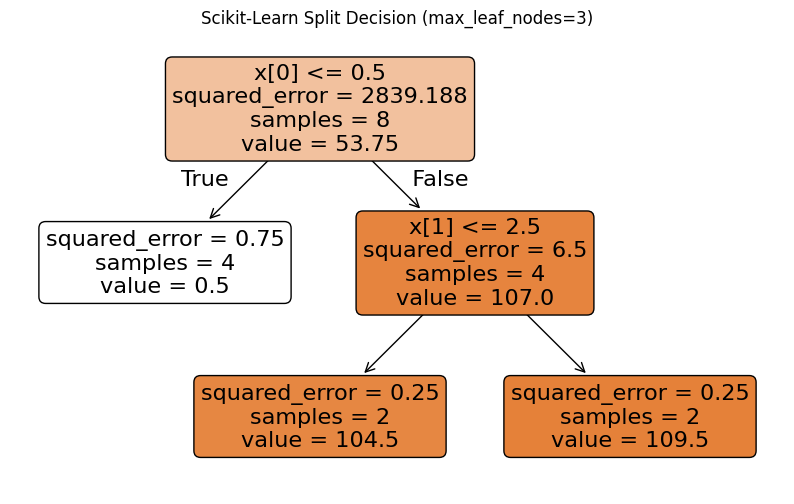

In [20]:
X = np.array([
    [0, 1], [0, 2], [0, 3], [0, 4],
    [1, 1], [1, 2], [1, 3], [1, 4]
])

y_L = np.array([0, 0, 0, 2])
y_R = np.array([104, 105, 109, 110])

y = np.concatenate([y_L, y_R])

model = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)
model.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree(model, filled=True, rounded=True)
plt.title("Scikit-Learn Split Decision (max_leaf_nodes=3)")
plt.show()

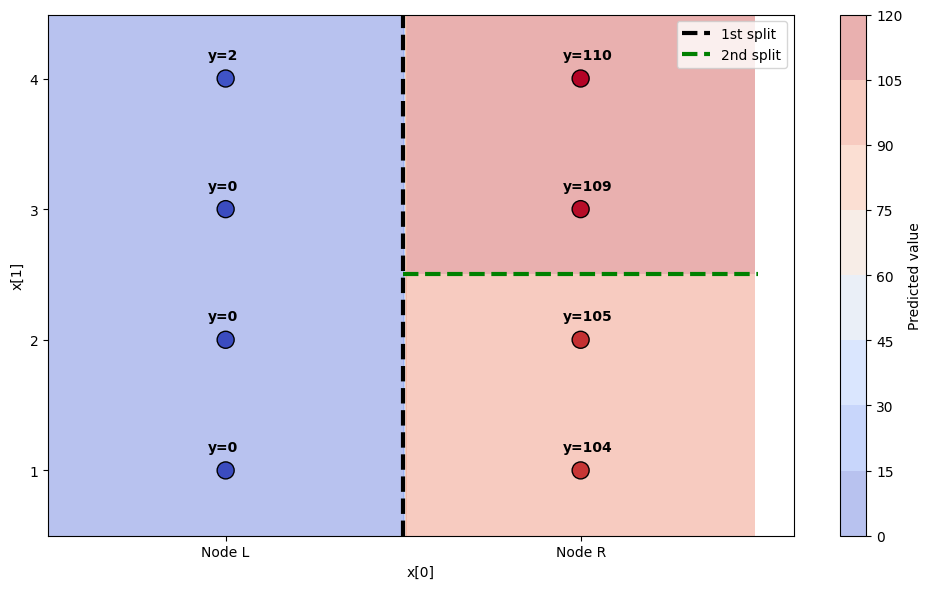

In [21]:
x_min, x_max = -0.5, 1.5
y_min, y_max = 0.5, 4.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

contour = plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.colorbar(contour, label='Predicted value')

scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=150, cmap='coolwarm', zorder=5)

for i in range(len(y)):
    plt.text(X[i, 0] - 0.05, X[i, 1] + 0.15, f'y={y[i]}', fontsize=10, fontweight='bold')

plt.axvline(x=0.5, color='black', linestyle='--', linewidth=3, label='1st split')
plt.hlines(y=2.5, xmin=0.5, xmax=1.5, color='green', linestyle='--', linewidth=3, label='2nd split')

plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.xticks([0, 1], ['Node L', 'Node R'])
plt.yticks([1, 2, 3, 4])
plt.legend()
plt.tight_layout()

plt.show()